# Day 6 Lab - Topic A (LiDAR-camera projection QA) - chạy trên Kaggle

Chỉ cần CPU (không cần bật GPU). Notebook này: lấy repo -> kiểm tra dữ liệu -> chạy toàn bộ thí nghiệm -> sinh `report/REPORT.md` -> nén kết quả để tải về.

**Cách lấy repo (chọn 1 trong 2):**
1. *Có internet (Settings -> Internet On)*: để `USE_GIT = True`, repo phải đã được push lên GitHub kèm thư mục `src/` và `starter/projection.py` đã sửa.
2. *Không internet*: nén cả thư mục repo thành 1 Kaggle Dataset (Add Data -> Upload), rồi đặt `USE_GIT = False` và sửa `INPUT_DIR` cho đúng tên dataset.

In [1]:
import os, shutil, subprocess

USE_GIT = True
REPO_URL = "https://github.com/Jikay-070203/NguyenThanhHoa-2A202602559-Track4-Day21.git"
INPUT_DIR = "/kaggle/input/nguyenthanhhoa-2a202602559-track4-day21"   # chỉ dùng khi USE_GIT = False
CLASS_NAME = "AI20K-2A202602559"   
STUDENT_NAME = "Nguyễn Thanh Hòa"  
REPO = "/kaggle/working/repo"

if os.path.exists(REPO):
    shutil.rmtree(REPO)
if USE_GIT:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO], check=True)
else:
    shutil.copytree(INPUT_DIR, REPO)      # /kaggle/input là read-only nên phải copy sang /kaggle/working
os.chdir(REPO)
print(os.getcwd(), os.listdir("."))

Cloning into '/kaggle/working/repo'...


/kaggle/working/repo ['CHECKPOINTS.md', 'RULES.md', 'report', '.gitattributes', 'README.md', 'RUBRIC.md', '.git', 'TOPICS.md', '.gitignore', 'data', 'results', 'SUBMISSION.md', 'requirements.txt', 'tools', 'starter', 'src']


In [2]:
# Kaggle đã có numpy, opencv, matplotlib, pandas. Chỉ kiểm tra phiên bản, KHÔNG pip install để tránh đổi phiên bản.
import numpy, cv2, pandas, matplotlib
print("numpy", numpy.__version__, "| opencv", cv2.__version__, "| pandas", pandas.__version__, "| matplotlib", matplotlib.__version__)
!python tools/verify_data.py --data-root data/kitti_mini
!python tools/verify_data.py --data-root data/nuscenes_mini_subset

numpy 2.1.3 | opencv 4.14.0 | pandas 2.3.3 | matplotlib 3.10.0
data/kitti_mini: 80/80 file đúng, tổng 55.0 MB
[PASS] Dữ liệu đầy đủ, dùng được.
data/nuscenes_mini_subset: 173/173 file đúng, tổng 74.0 MB
[PASS] Dữ liệu đầy đủ, dùng được.


In [3]:
# Chạy toàn bộ, gồm cả bonus B1, B2, B6 (khoảng 20-40 phút trên CPU Kaggle).
# Chạy thử nhanh: thêm --max-frames 8 --max-nusc-frames 8 --skip-latency
# Chỉ chạy lại bonus: !python -m src.exp_compare ; !python -m src.exp_stress ; !python -m src.exp_synthetic ; rồi !python -m src.make_report --class-name "{CLASS_NAME}"
!python -m src.run_all --class-name "{CLASS_NAME}" --student-name "{STUDENT_NAME}"


===== 1/10 demo + kiem tra tay CP2 =====
[PASS] z_cam cua diem (10,0,0): expected ~9.73, got 9.727
[PASS] pixel (u,v) cua diem (10,0,0): expected ~(614,175), got (614.0,175.0)
[PASS] diem (-10,0,0) o phia sau xe bi loai: expected mask=False, got mask=False
[PASS] NaN/Inf khong lam crash, chi diem hop le con lai: expected mask=[F,F,T], got mask=[False, False, True]
demo_01_near_kitti_000019: inside_image=18792/115697, nearest label=5.5 m
demo_02_mid_kitti_000011: inside_image=19946/108004, nearest label=4.1 m
demo_03_far_kitti_000004: inside_image=19063/115976, nearest label=38.3 m
demo_04_synthetic_000000: inside_image=3910/23930, nearest label=5.7 m
demo_05_nuscenes_day_scene-0103_010: inside_image=3120/34720, nearest label=7.4 m
demo_06_nuscenes_night_scene-1094_010: inside_image=3592/34688, nearest label=6.8 m
-> results/figures
[1/10 demo + kiem tra tay CP2] xong sau 2s

===== 2/10 sweep calibration drift =====
[kitti] 5/20 frame, 10s
[kitti] 10/20 frame, 19s
[kitti] 15/20 frame, 

In [4]:
!python tools/check_submission.py

[PASS] report/REPORT.md đủ 6 mục
[PASS] report/REPORT.md đã điền hết
[PASS] report/REPORT.md có dòng **MSSV:** hợp lệ (chỉ chữ và số)
[PASS] results/ có >= 1 bảng số liệu (.csv)
[PASS] results/ có >= 1 ảnh/video demo
[PASS] results/ có ảnh failure case (tên chứa 'fail')
[PASS] Không có file > 20 MB
[PASS] Không commit dữ liệu thô / checkpoint ngoài thư mục data/
[PASS] Không commit .env
[PASS] Không lộ API key / token

KẾT QUẢ: SẴN SÀNG NỘP


results/figures/alignment_score_vs_drift.png


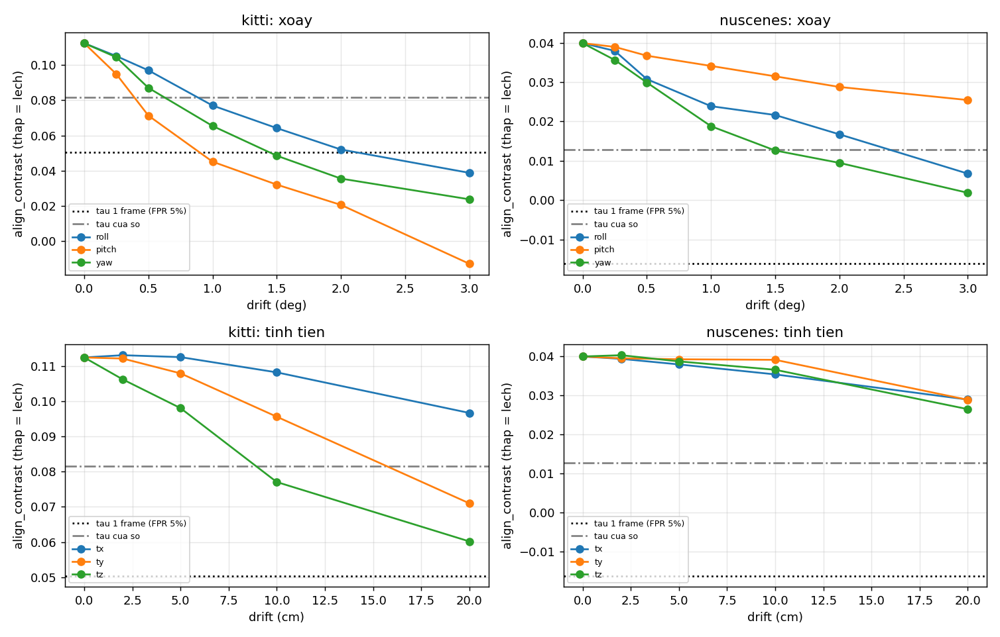

results/figures/alignment_tpr_vs_drift.png


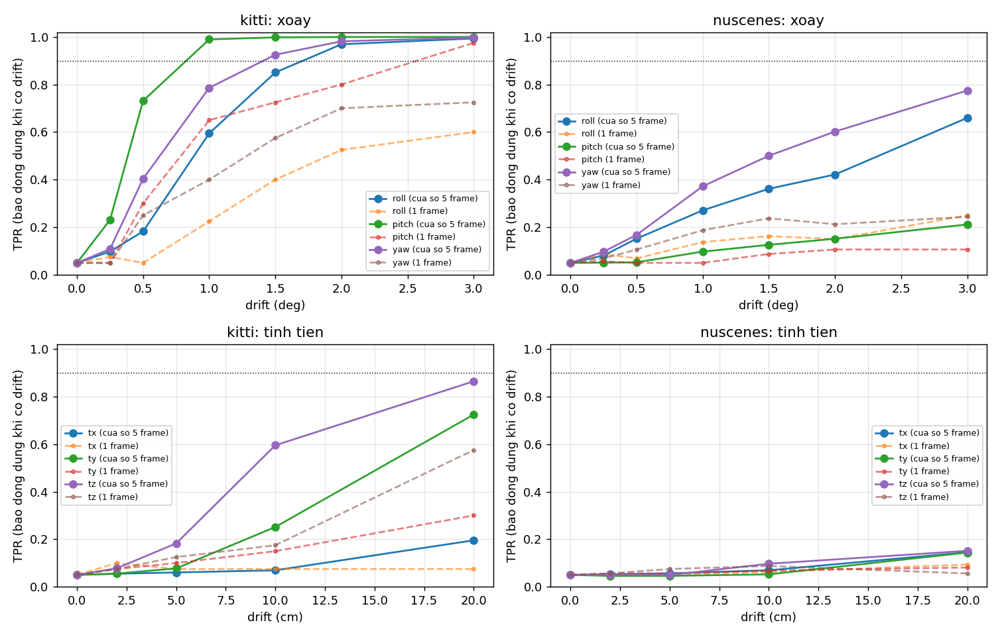

results/figures/compare_methods_auc.png


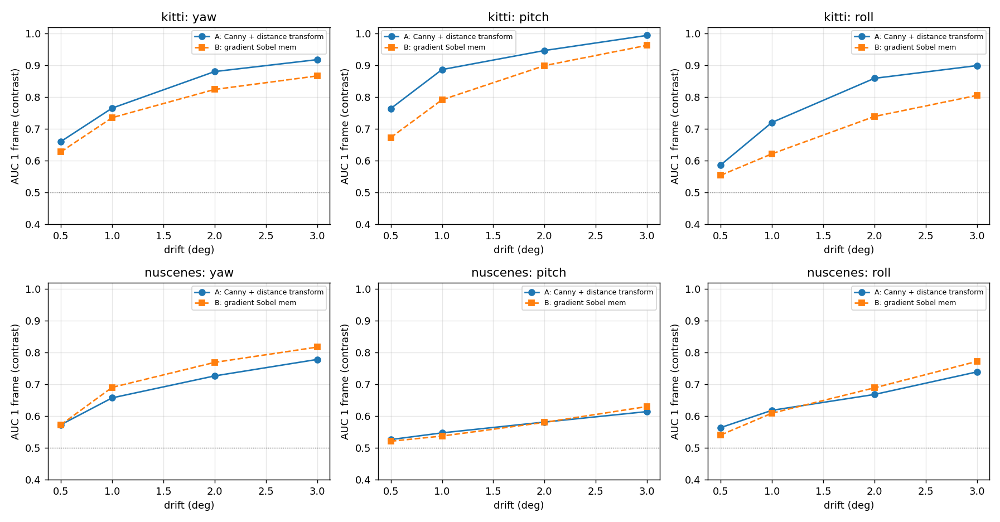

results/figures/demo_01_near_kitti_000019.png


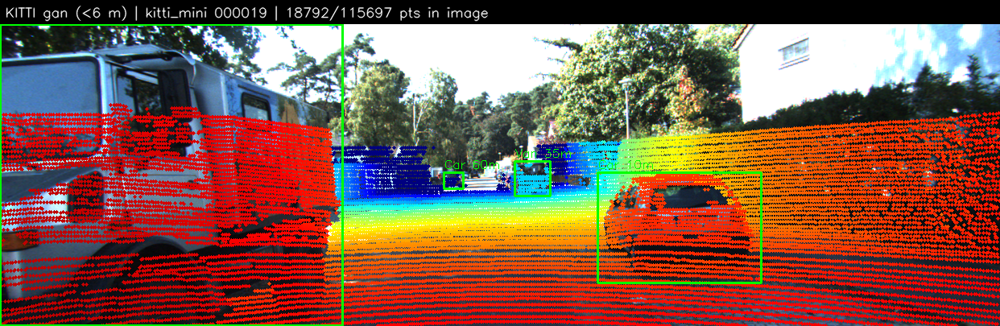

results/figures/demo_02_mid_kitti_000011.png


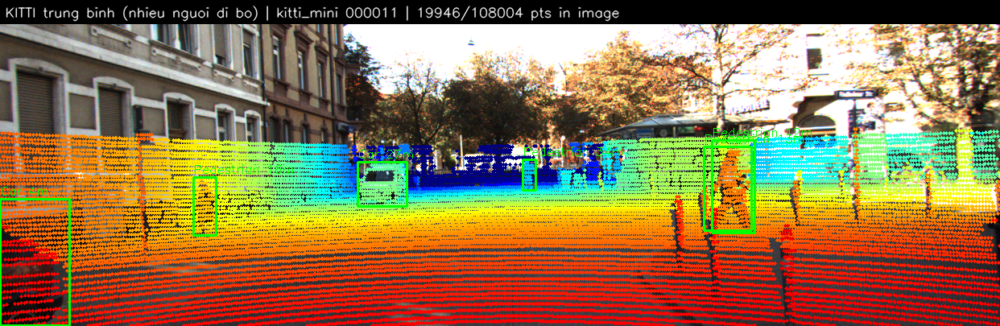

results/figures/demo_03_far_kitti_000004.png


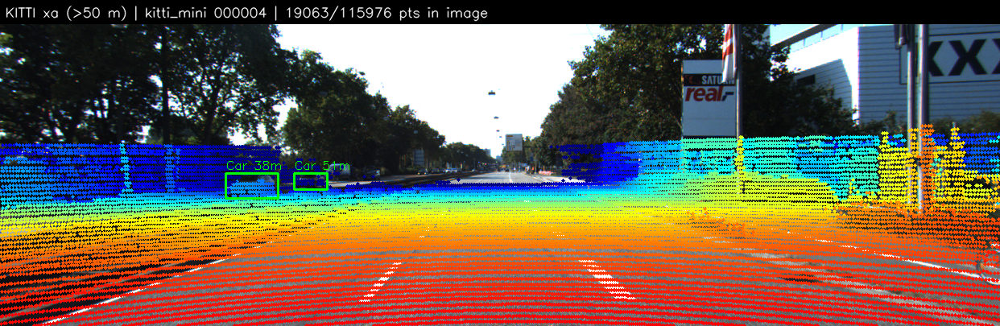

results/figures/demo_04_synthetic_000000.png


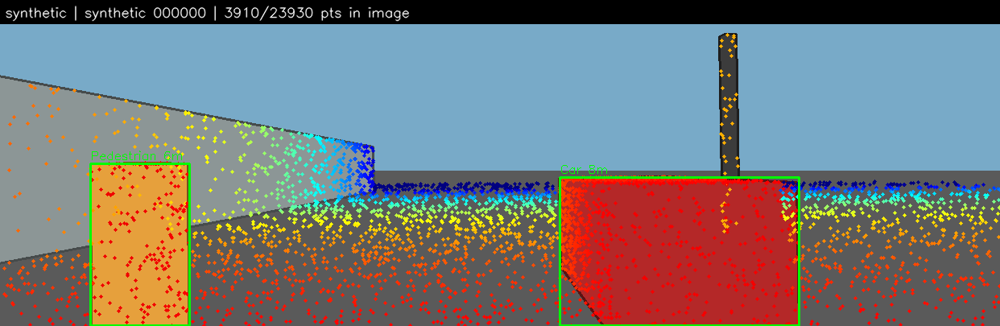

results/figures/demo_05_nuscenes_day_scene-0103_010.png


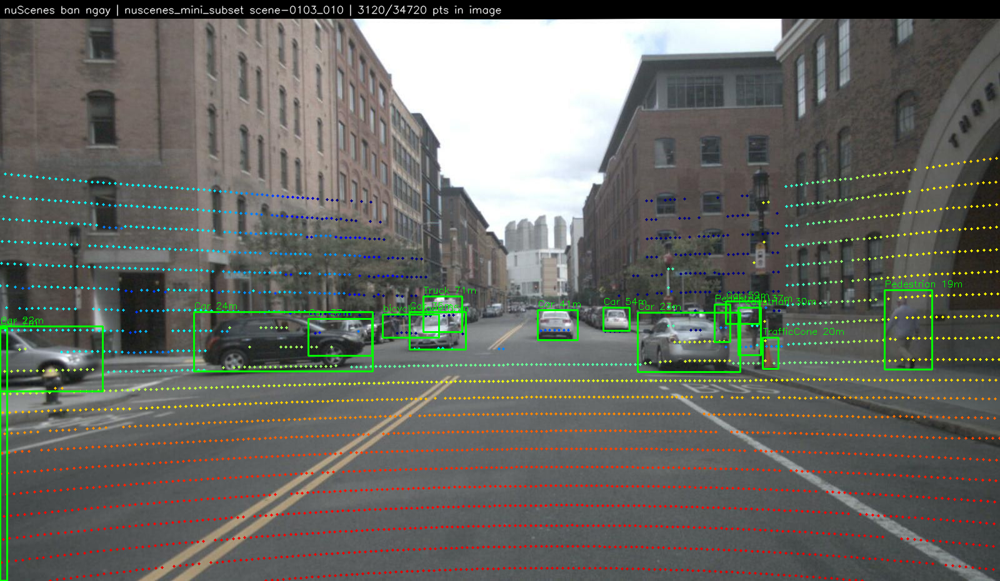

results/figures/demo_06_nuscenes_night_scene-1094_010.png


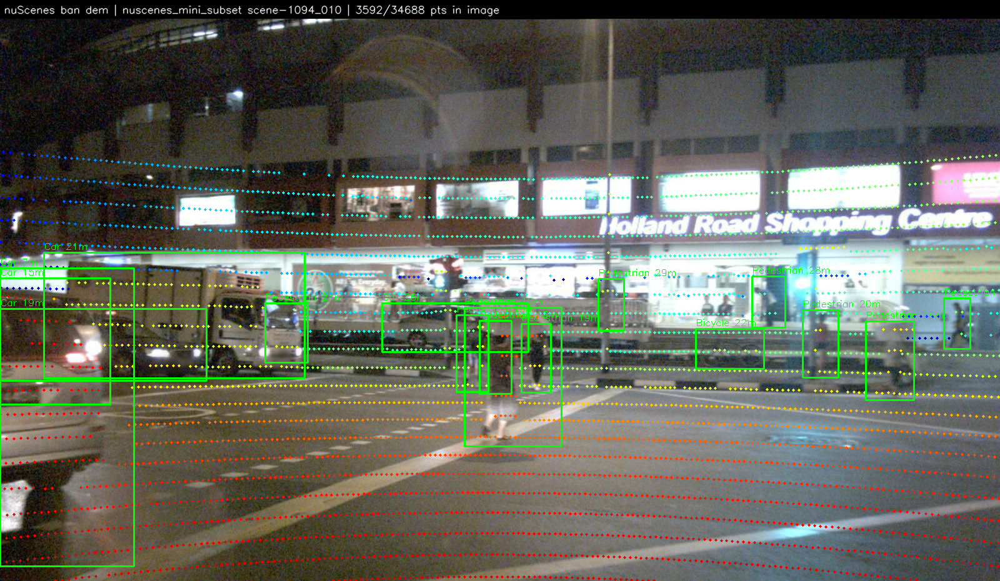

results/figures/drift_gallery_kitti_000011.png


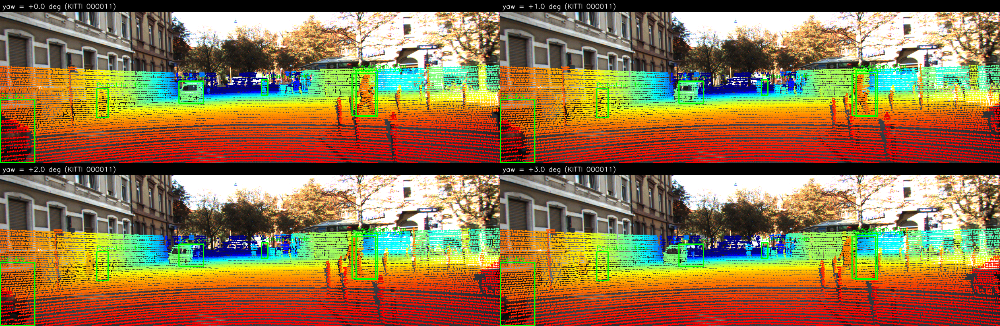

results/figures/fail_01_yaw_1deg_pedestrian_000011.png


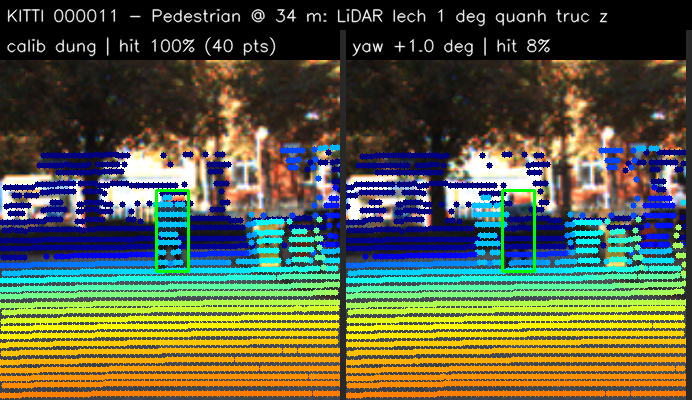

results/figures/fail_02_time_sync_noego_scene-0103_001.png


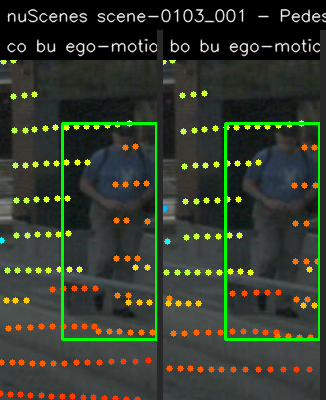

results/figures/fail_03_alignment_blind_nuscenes_scene-0103_006_roll3deg.png


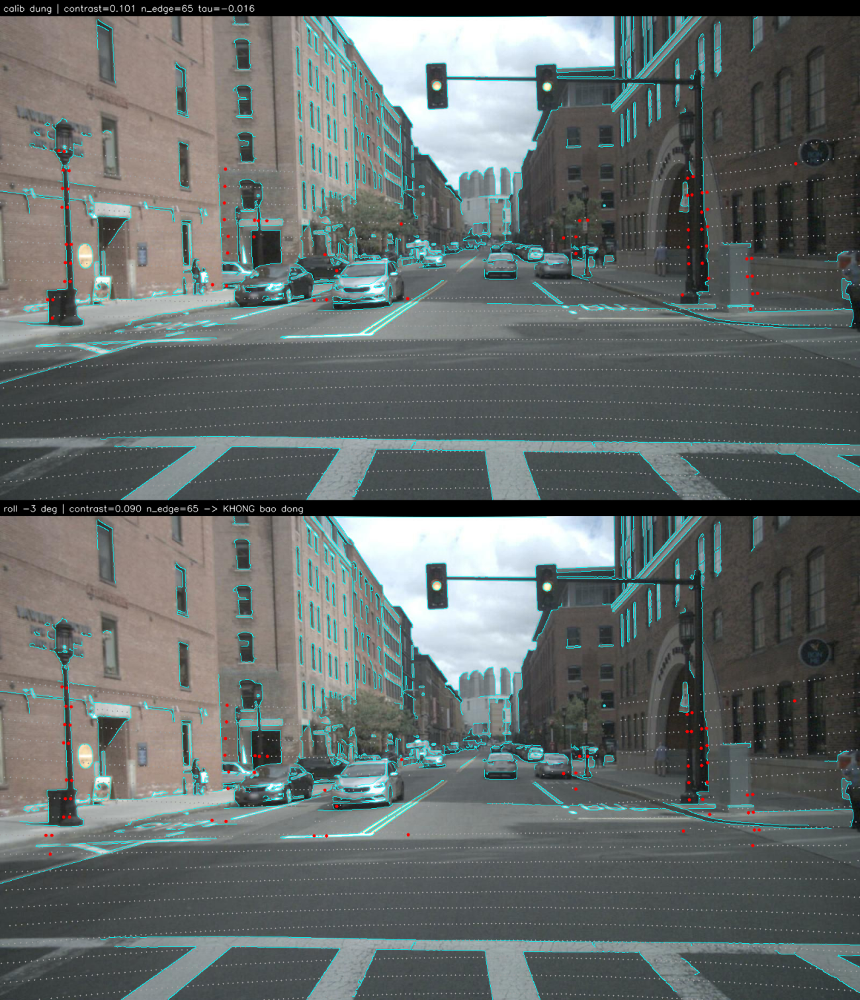

results/figures/hit_rate_by_distance.png


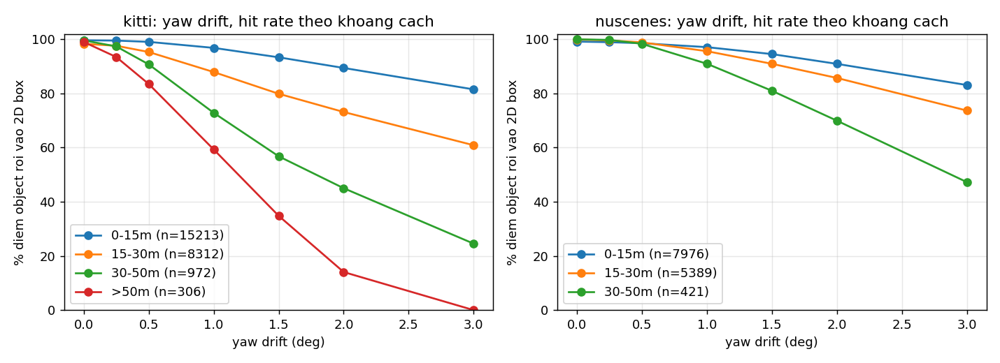

results/figures/hit_rate_vs_drift.png


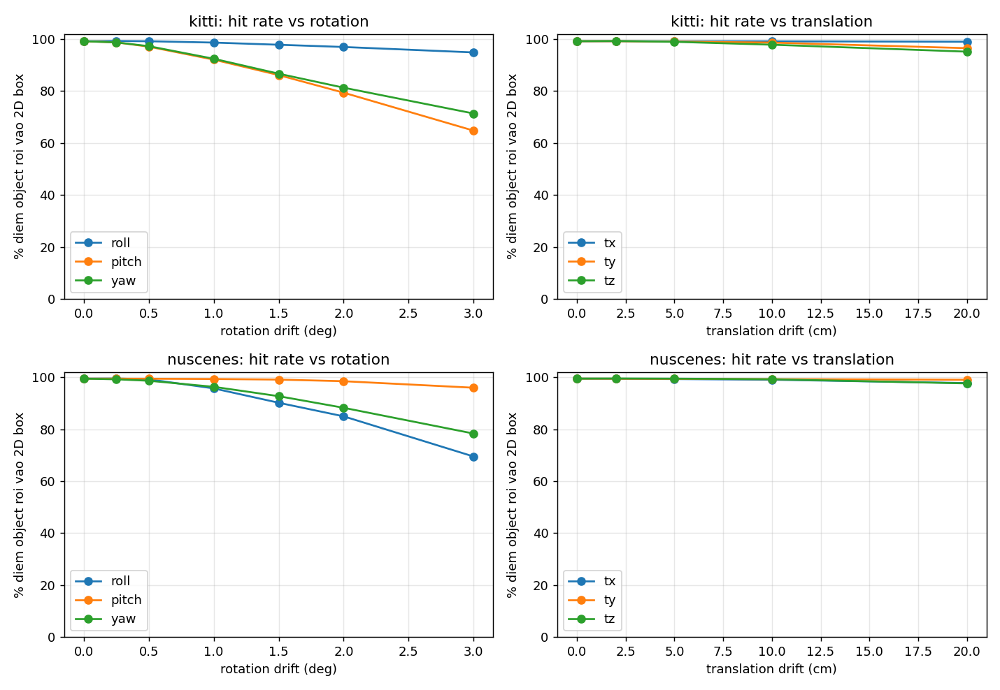

results/figures/stress_degradation.png


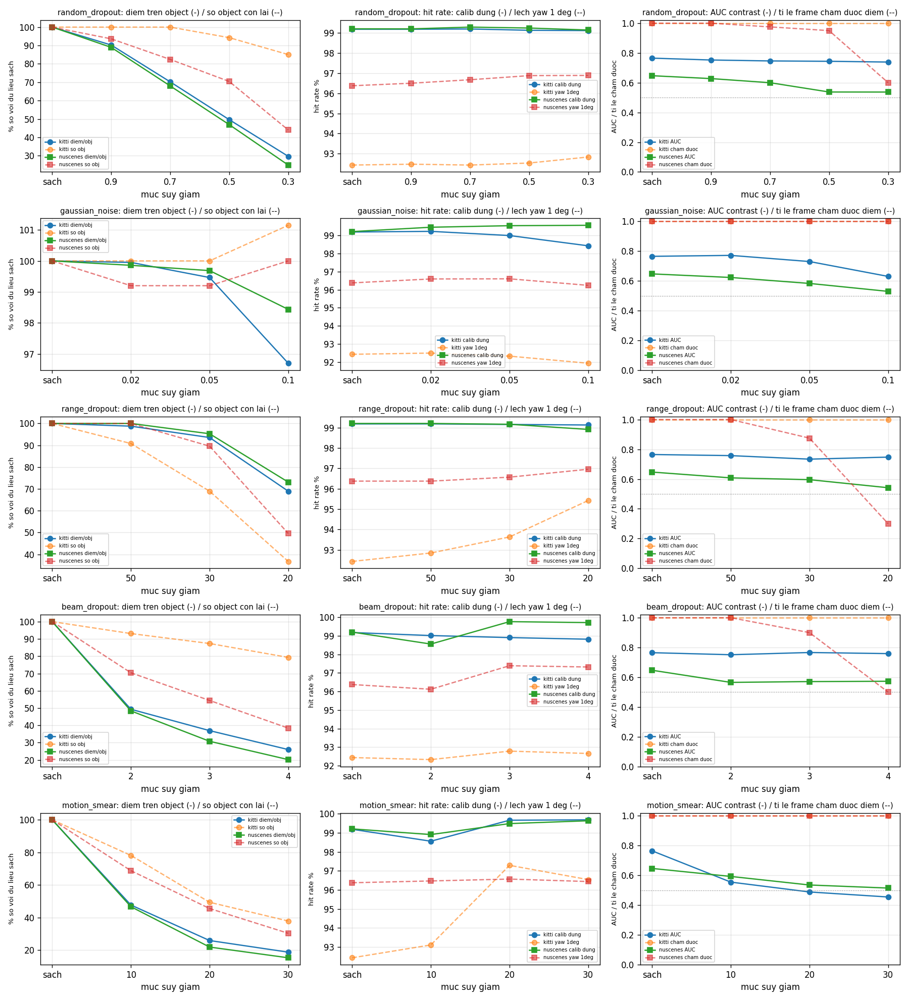

results/figures/synthetic_fault_sector_bev.png


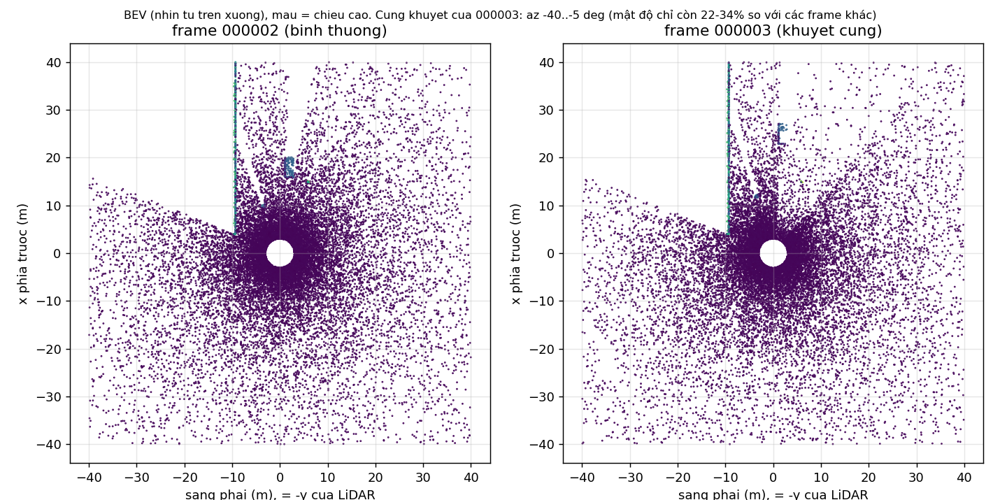

results/figures/synthetic_faults_dashboard.png


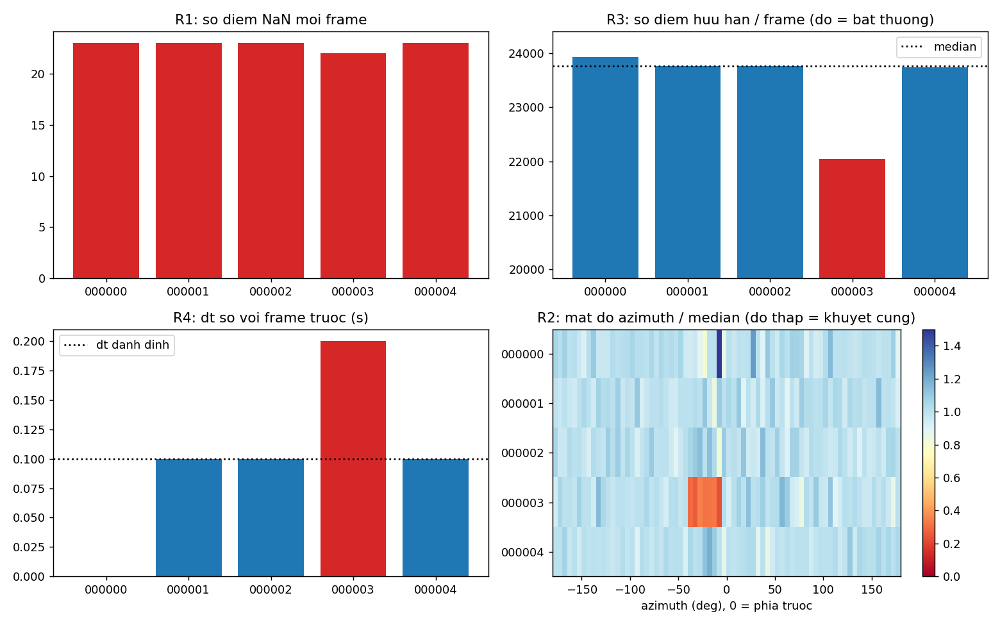

In [5]:
# Xem nhanh vài ảnh kết quả
import glob
from IPython.display import Image, display
for p in sorted(glob.glob("results/figures/*.png"))[:40]:
    print(p)
    display(Image(p, width=900))

In [6]:
# Nén results/ và report/ để tải về (file zip nằm NGOÀI repo, đừng commit file zip vào repo)
!cd /kaggle/working/repo && zip -qr /kaggle/working/lab6_outputs.zip results report
!ls -la /kaggle/working/lab6_outputs.zip

-rw-r--r-- 1 root root 14499542 Oct  7 18:18 /kaggle/working/lab6_outputs.zip
